In [420]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [421]:
df = pd.read_csv("xAPI-Edu-Data.csv")

Understanding the data set

In [422]:
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [423]:
df.shape

(480, 17)

In [424]:
df.describe(include="all")

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
count,480,480,480,480,480,480,480,480,480,480.000000,480.000000,480.000000,480.000000,480,480,480,480
unique,2,14,14,3,10,3,12,2,2,NaN,NaN,NaN,NaN,2,2,2,3
top,M,KW,KuwaIT,MiddleSchool,G-02,A,IT,F,Father,NaN,NaN,NaN,NaN,Yes,Good,Under-7,M
freq,305,179,180,248,147,283,95,245,283,NaN,NaN,NaN,NaN,270,292,289,211
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,46.775000,54.797917,37.918750,43.283333,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.779223,33.080007,26.611244,27.637735,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.750000,20.000000,14.000000,20.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.000000,65.000000,33.000000,39.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75.000000,84.000000,58.000000,70.000000,NaN,NaN,NaN,NaN


In [425]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [426]:
df.isnull().sum()

,0
gender,0
NationalITy,0
PlaceofBirth,0
StageID,0
GradeID,0
SectionID,0
Topic,0
Semester,0
Relation,0
raisedhands,0


Data Visualization

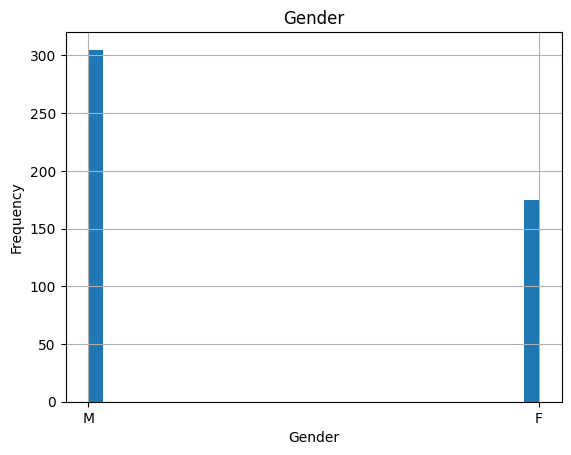

In [427]:
#for visulaization:
# Histogram for gender count
df['gender'].hist(bins=30)
plt.title("Gender")
plt.xlabel("Gender")
plt.ylabel("Frequency")
plt.show()


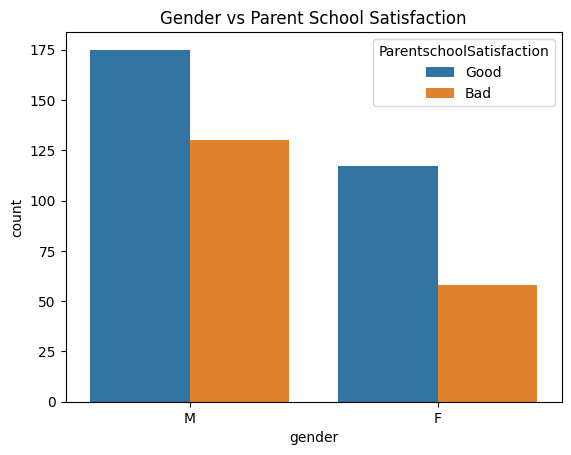

In [428]:
sns.countplot(x='gender', hue='ParentschoolSatisfaction', data=df)
plt.title("Gender vs Parent School Satisfaction")
plt.show()

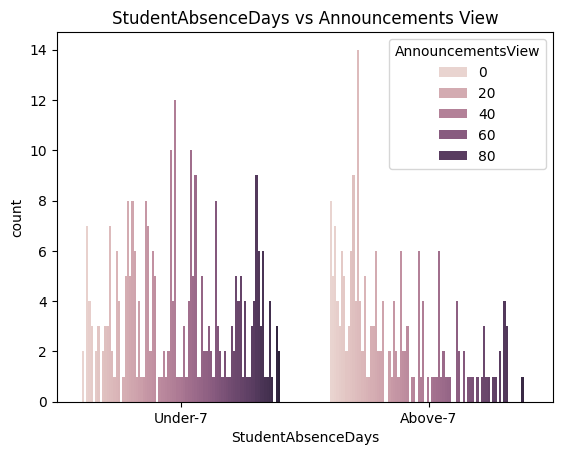

In [429]:
sns.countplot(x='StudentAbsenceDays', hue='AnnouncementsView', data=df)
plt.title("StudentAbsenceDays vs Announcements View")
plt.show()

Boxplots to understand outliers


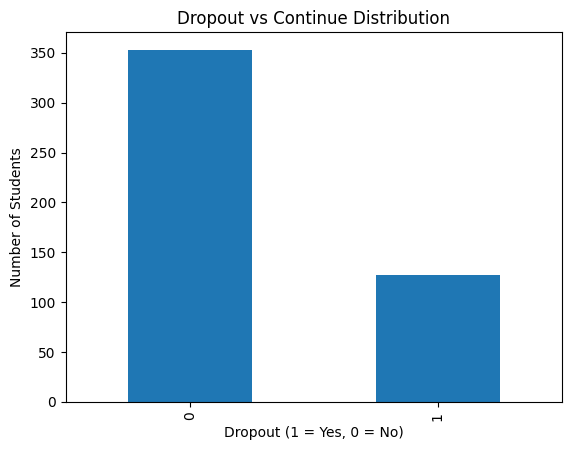

In [430]:
df["dropout"] = df["Class"].map({"L":1, "M":0, "H":0})
df["dropout"].value_counts().plot(
    kind="bar",
    title="Dropout vs Continue Distribution"
)
plt.xlabel("Dropout (1 = Yes, 0 = No)")
plt.ylabel("Number of Students")
plt.show()

In [431]:
def plotting_boxplot(feature):
  df.boxplot(column=feature, by="dropout")
  plt.title(f"{feature} vs Dropout")
  plt.suptitle("")
  plt.xlabel("Dropout (1 = Yes)")
  plt.ylabel(feature)
  plt.show()

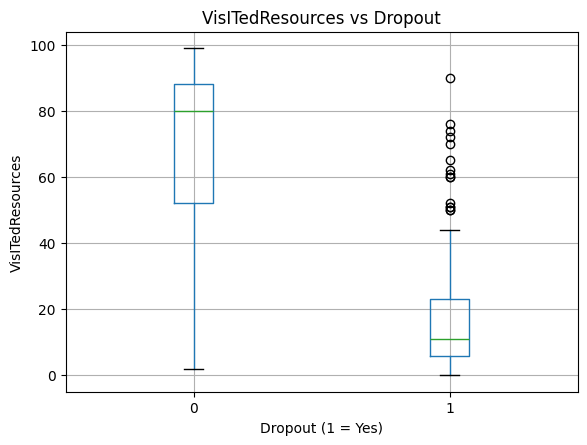

In [432]:
plotting_boxplot("VisITedResources")

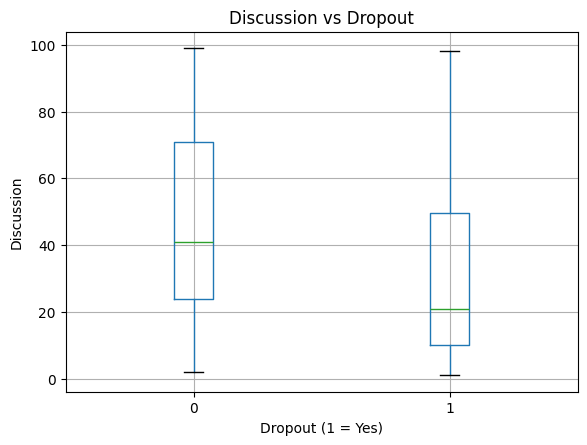

In [433]:
plotting_boxplot("Discussion")

In [434]:
def detect_outlier(data,col):
  Q1 = data[col].quantile(0.25)
  Q3 = data[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound= Q1 - 3.0 * IQR
  upper_bound= Q3 + 3.0 *IQR
  return lower_bound, upper_bound

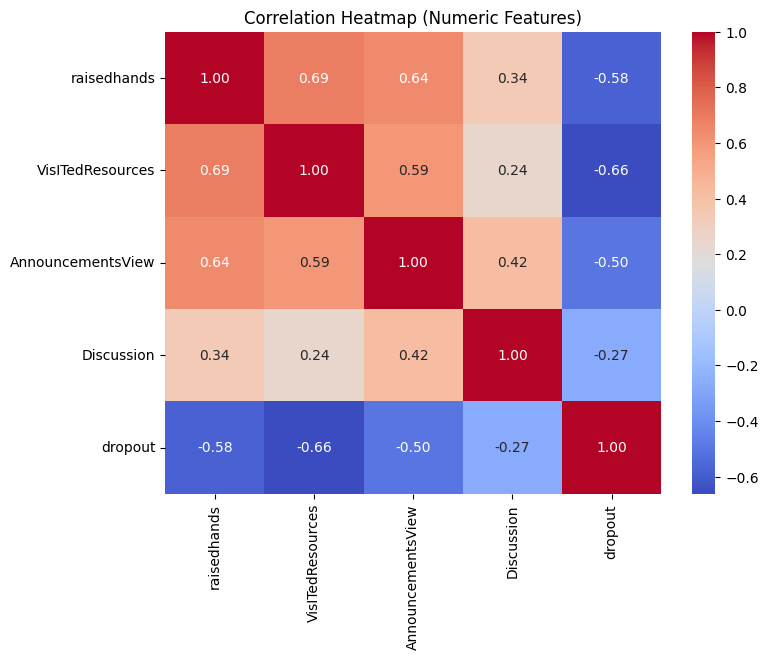

In [435]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correcting the casing of column names to match the DataFrame
num_cols = [
    "raisedhands",
    "VisITedResources",
    "AnnouncementsView",
    "Discussion",
    "dropout"
]

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

In [436]:
columns_to_encode = ['gender','NationalITy','PlaceofBirth','StageID','GradeID','SectionID',
    'Topic','Semester','Relation','ParentAnsweringSurvey','ParentschoolSatisfaction','StudentAbsenceDays']


In [437]:
df_encoded = pd.get_dummies(df, columns=columns_to_encode, drop_first=True)


In [438]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 62 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   raisedhands                    480 non-null    int64 
 1   VisITedResources               480 non-null    int64 
 2   AnnouncementsView              480 non-null    int64 
 3   Discussion                     480 non-null    int64 
 4   Class                          480 non-null    object
 5   dropout                        480 non-null    int64 
 6   gender_M                       480 non-null    bool  
 7   NationalITy_Iran               480 non-null    bool  
 8   NationalITy_Iraq               480 non-null    bool  
 9   NationalITy_Jordan             480 non-null    bool  
 10  NationalITy_KW                 480 non-null    bool  
 11  NationalITy_Lybia              480 non-null    bool  
 12  NationalITy_Morocco            480 non-null    bool  
 13  Natio

In [439]:
df['activity_score'] = df['raisedhands'] + df['VisITedResources'] + df['AnnouncementsView'] + df['Discussion']
df['parent_engaged'] = df['ParentAnsweringSurvey'].map({'Yes':1, 'No':0})


In [440]:
df_encoded['activity_score'] = df['activity_score']
df_encoded['parent_engaged'] = df['parent_engaged']

In [441]:
drop_columns=['PlaceofBirth','Relation','SectionID','dropout','Class']

In [442]:
X = df_encoded.drop(columns=drop_columns, errors='ignore')
y = df_encoded['dropout']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

In [443]:
scaler = StandardScaler()

# Fit on training data only
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [444]:
def calculate_confusionmatrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Accuracy: 0.925
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        88
           1       0.93      0.78      0.85        32

    accuracy                           0.93       120
   macro avg       0.93      0.88      0.90       120
weighted avg       0.93      0.93      0.92       120



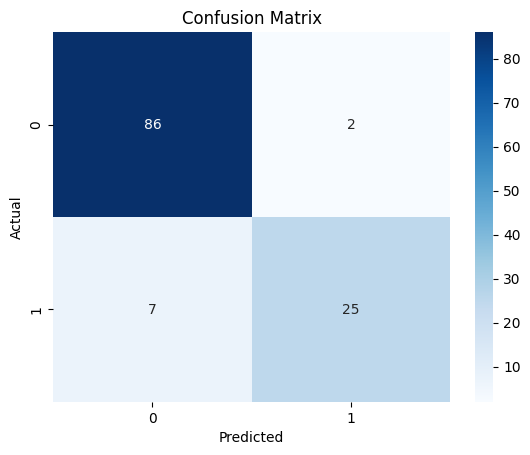

In [445]:
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
# Predict on the test set instead of the training set
y_pred_lr = lr_model.predict(X_test_scaled)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", accuracy_lr)

print(classification_report(y_test, y_pred_lr))
calculate_confusionmatrix(y_test,y_pred_lr)

Accuracy: 0.925
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        88
           1       0.96      0.75      0.84        32

    accuracy                           0.93       120
   macro avg       0.94      0.87      0.90       120
weighted avg       0.93      0.93      0.92       120



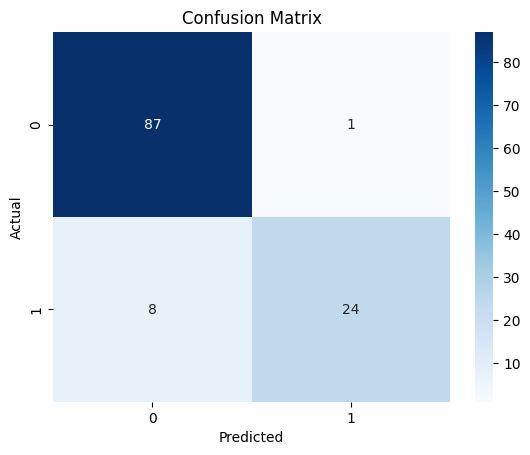

In [446]:
rfc_model = RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=42)
rfc_model.fit(X_train_scaled, y_train)

y_pred_rfc = rfc_model.predict(X_test_scaled)
accuracy_rfc = accuracy_score(y_test, y_pred_rfc)
print("Accuracy:", accuracy_rfc)

print(classification_report(y_test, y_pred_rfc))

calculate_confusionmatrix(y_test, y_pred_rfc)


Accuracy: 0.9416666666666667
              precision    recall  f1-score   support

           0       0.96      0.97      0.96        88
           1       0.90      0.88      0.89        32

    accuracy                           0.94       120
   macro avg       0.93      0.92      0.92       120
weighted avg       0.94      0.94      0.94       120



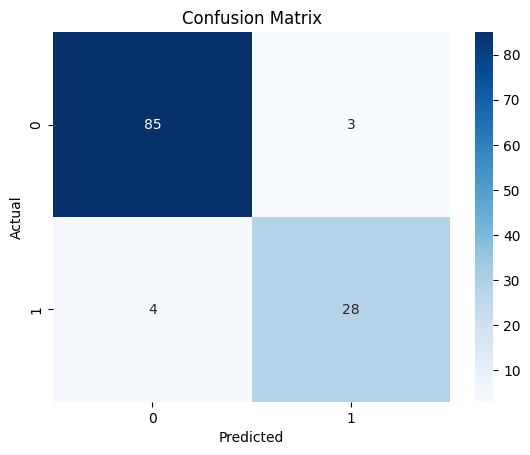

In [447]:

xgb_model = XGBClassifier(n_estimators=200, scale_pos_weight=(len(y_train)-sum(y_train))/sum(y_train), random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print("Accuracy:", accuracy_xgb)

print(classification_report(y_test, y_pred_xgb))

calculate_confusionmatrix(y_test, y_pred_xgb)

In [448]:
def risk_label(score):
    if score >= 0.7:
        return "High"
    elif score >= 0.4:
        return "Medium"
    else:
        return "Low"

# LR
risk_scores_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
risk_labels_lr = [risk_label(s) for s in risk_scores_lr]

# RFC
risk_scores_rfc = rfc_model.predict_proba(X_test_scaled)[:, 1]
risk_labels_rfc = [risk_label(s) for s in risk_scores_rfc]

# XGB
risk_scores_xgb = xgb_model.predict_proba(X_test)[:, 1]
risk_labels_xgb = [risk_label(s) for s in risk_scores_xgb]

In [449]:
predictions_xgb = pd.DataFrame({
    'student_id': X_test.index,
    'risk_score': risk_scores_xgb,
    'risk_label': risk_labels_xgb,
    'predicted_dropout': y_pred_xgb
})

predictions_xgb.to_csv("predictions_xgb.csv", index=False)



In [450]:
predictions_lr = pd.DataFrame({
    'student_id': X_test.index,
    'risk_score': risk_scores_lr,
    'risk_label': risk_labels_lr,
    'predicted_dropout': y_pred_lr
})

predictions_lr.to_csv("predictions_lr.csv", index=False)

In [451]:
predictions_rfc = pd.DataFrame({
    'student_id': X_test.index,
    'risk_score': risk_scores_rfc,
    'risk_label': risk_labels_rfc,
    'predicted_dropout': y_pred_rfc
})

predictions_rfc.to_csv("predictions_rfc.csv", index=False)

In [452]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

In [453]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [454]:
import pickle
# Save training columns
with open("columns.pkl", "wb") as f:
    pickle.dump(list(X_train.columns), f)
